### Setup (Clone from Github, import modules)

Clone from github to access datasets/code and import modules

In [1]:
!git clone https://github.com/PacktPublishing/Hands-On-Artificial-Intelligence-for-Cybersecurity.git

Cloning into 'Hands-On-Artificial-Intelligence-for-Cybersecurity'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 99 (delta 12), reused 15 (delta 6), pack-reused 77 (from 1)
Receiving objects: 100% (99/99), 1000.68 KiB | 4.10 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [2]:
!git clone https://github.com/trekhleb/homemade-machine-learning.git

Cloning into 'homemade-machine-learning'...
remote: Enumerating objects: 1459, done.
remote: Counting objects: 100% (486/486), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 1459 (delta 421), reused 407 (delta 406), pack-reused 973 (from 1)
Receiving objects: 100% (1459/1459), 14.48 MiB | 4.94 MiB/s, done.
Resolving deltas: 100% (861/861), done.


Rename file

In [3]:
!cp homemade-machine-learning/homemade/anomaly_detection/gaussian_anomaly_detection.py gaussian_anomaly_detection.py

Import modules

In [4]:
import warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
import csv
import sklearn
import nltk
nltk.download('popular')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
from textblob import TextBlob
from gaussian_anomaly_detection import GaussianAnomalyDetection

from sklearn.linear_model import *
from sklearn.tree import *
from sklearn.naive_bayes import *
from sklearn.neighbors import *
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

import matplotlib.pyplot as plt
%matplotlib inline

def get_tokens(msg):
    return TextBlob(str(msg)).words

def get_lemmas(msg):
    lemmas = []
    words  = get_tokens(msg)

    for word in words:
        lemmas.append(word.lemma)

    return lemmas

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

### Network anomalies

Read in network logs dataset

In [5]:
dataset = pd.read_csv('Hands-On-Artificial-Intelligence-for-Cybersecurity/Chapter05/datasets/network-logs.csv')

Preview the data

In [6]:
dataset.head(10)

,REMOTE_PORT,LATENCY,THROUGHPUT,ANOMALY
0,21,15.942875,16.202998,0
1,20,12.666451,15.899084,1
2,80,13.894550,12.958008,0
3,21,13.620813,15.459475,0
4,21,15.705485,15.339565,0
5,23,15.593190,15.612381,0
6,21,15.489068,15.640874,0
7,80,15.527048,15.635680,0
8,21,14.075067,15.765315,0
9,53,12.953650,15.823285,0


Separate features and labels

In [7]:
samples = dataset.iloc[:, [1, 2]].values
targets = dataset['ANOMALY'].values

In [8]:
samples[0:5]

array([[15.94287532, 16.20299807],
       [12.66645095, 15.89908374],
       [13.89454962, 12.95800822],
       [13.62081292, 15.45947525],
       [15.70548485, 15.33956527]])

In [9]:
targets[0:5]

array([0, 1, 0, 0, 0])

Create histogram

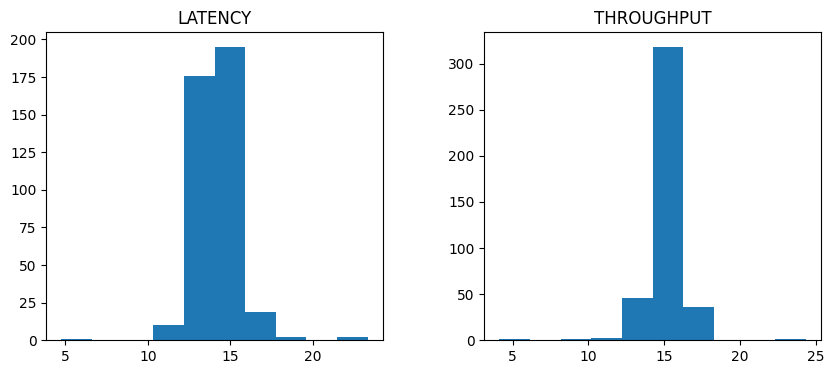

In [10]:
hist_dist = dataset[['LATENCY', 'THROUGHPUT']].hist(grid=False, figsize=(10,4))

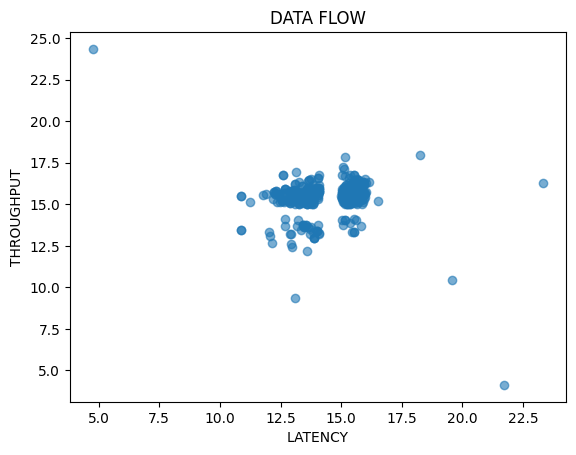

In [11]:
data = dataset[['LATENCY', 'THROUGHPUT']].values

plt.scatter(data[:, 0], data[:, 1], alpha=0.6)
plt.xlabel('LATENCY')
plt.ylabel('THROUGHPUT')
plt.title('DATA FLOW')
plt.show()

Gaussian Anomaly Detection

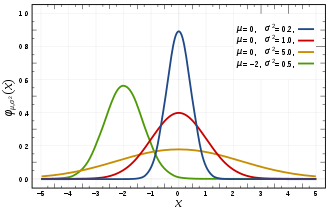  
https://en.wikipedia.org/wiki/Normal_distribution  
parameters  
mu: mean  
sigma squared: variance

In [12]:
gaussian_anomaly_detection = GaussianAnomalyDetection(data)

print('mu param estimation: ')
print(gaussian_anomaly_detection.mu_param)

print('\n')

print('sigma squared estimation: ')
print(gaussian_anomaly_detection.sigma_squared)

mu param estimation: 
[14.42070163 15.39209133]


sigma squared estimation: 
[2.09674794 1.37224807]


Find threshold value estimate

In [13]:
targets = dataset['ANOMALY'].values.reshape((data.shape[0], 1))
probs = gaussian_anomaly_detection.multivariate_gaussian(data)

(threshold, F1, precision_, recall_, f1_) = gaussian_anomaly_detection.select_threshold(targets, probs)

print('\n')

print('threshold estimation: ')
print(threshold)



threshold estimation: 
0.00027176836728971885


Find and plot outliers

[]

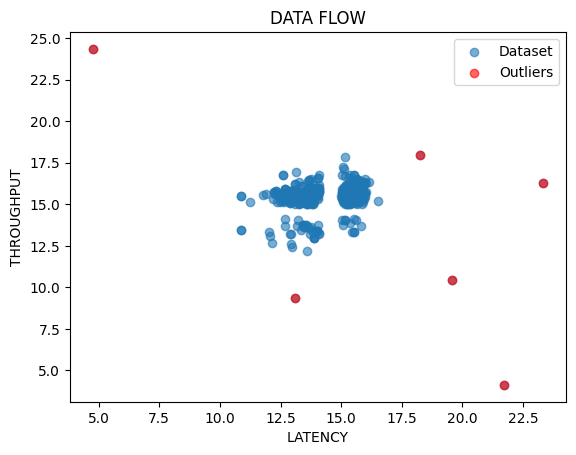

In [14]:
outliers = np.where(probs < threshold)[0]

# Plot original data.
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, label='Dataset')
plt.xlabel('LATENCY')
plt.ylabel('THROUGHPUT')
plt.title('DATA FLOW')

# Plot the outliers.
plt.scatter(data[outliers, 0], data[outliers, 1], alpha=0.6, c='red', label='Outliers')

# Display plots.
plt.legend()
plt.plot()

Split data into training and test subsets

In [15]:
training_samples, testing_samples, training_targets, testing_targets = train_test_split(
         samples, targets, test_size=0.3, random_state=0)

K-Nearest Neighbors Classifier

k = 2

In [16]:
knc = KNeighborsClassifier(n_neighbors=2)

Train the model

In [17]:
knc.fit(training_samples,training_targets)

KNeighborsClassifier(n_neighbors=2)

Make predictions on test data

In [18]:
knc_prediction = knc.predict(testing_samples)

Check the accuracy of the trained model. How many predictions did it get right?

In [19]:
knc_accuracy = 100.0 * accuracy_score(testing_targets, knc_prediction)
print ("K-Nearest Neighbours accuracy: " + str(knc_accuracy))

K-Nearest Neighbours accuracy: 95.90163934426229


### Spam email

Load spam dataset

In [20]:
sms = pd.read_csv('Hands-On-Artificial-Intelligence-for-Cybersecurity/Chapter03/datasets/sms_spam_no_header.csv', sep=',', names=["type", "text"])

Preview the data

In [21]:
sms.head(10)

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


Split data into train and test

In [22]:
text_train, text_test, type_train, type_test = train_test_split(sms['text'], sms['type'], test_size=0.3)

Convert text to tokens that can be analyzed

In [23]:
bow = CountVectorizer(analyzer=get_lemmas).fit(text_train)

Get token counts out of original text

In [24]:
sms_bow = bow.transform(text_train)

Adjust weighting so that frequently occurring words have less impact

In [25]:
tfidf = TfidfTransformer().fit(sms_bow)

In [26]:
sms_tfidf = tfidf.transform(sms_bow)

Train a Multinomial Naive Bayes model

In [27]:
spam_detector = MultinomialNB().fit(sms_tfidf, type_train)

Predict one message

In [28]:
msg = sms['text'][25]
msg

"Just forced myself to eat a slice. I'm really not hungry tho. This sucks. Mark is getting worried. He knows I'm sick when I turn down pizza. Lol"

In [29]:
msg_bow = bow.transform([msg])
msg_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 27 stored elements and shape (1, 8839)>

In [30]:
msg_tfidf = tfidf.transform(msg_bow)
msg_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27 stored elements and shape (1, 8839)>

In [31]:
print ('predicted:', spam_detector.predict(msg_tfidf)[0])
print ('expected:', sms.type[25])

predicted: ham
expected: ham


Predict on all

In [32]:
sms_test = bow.transform(text_test)
sms_tfidf_test = tfidf.transform(sms_test)
predictions = spam_detector.predict(sms_tfidf_test)

Print accuracy

In [33]:
print ('accuracy', accuracy_score(sms['type'][:len(predictions)], predictions))

accuracy 0.8057381948595338


In [34]:
print (classification_report(sms['type'][:len(predictions)], predictions))

              precision    recall  f1-score   support

         ham       0.86      0.92      0.89      1436
        spam       0.16      0.08      0.11       237

    accuracy                           0.81      1673
   macro avg       0.51      0.50      0.50      1673
weighted avg       0.76      0.81      0.78      1673



### Phishing

Load phishing dataset

In [35]:
phish = pd.read_csv('Hands-On-Artificial-Intelligence-for-Cybersecurity/Chapter03/datasets/phishing_dataset.csv', delimiter=',')

In [36]:
phish.head(10)

,-1,1,1.1,1.2,-1.1,-1.2,-1.3,-1.4,-1.5,1.3,...,1.9,1.10,-1.11,-1.12,-1.13,-1.14,1.11,1.12,-1.15,-1.16
0,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1
5,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
6,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
7,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,-1,1,1,1,0,1,1
8,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1
9,1,1,1,1,1,-1,0,1,1,1,...,1,1,-1,1,1,1,1,-1,-1,1


In [37]:
phishing_dataset = np.genfromtxt('Hands-On-Artificial-Intelligence-for-Cybersecurity/Chapter03/datasets/phishing_dataset.csv', delimiter=',', dtype=np.int32)
samples = phishing_dataset[:,:-1]
targets = phishing_dataset[:, -1]

Split into train and test

In [38]:
training_samples, testing_samples, training_targets, testing_targets = train_test_split(
         samples, targets, test_size=0.2, random_state=0)

Train a decision tree model

In [39]:
tree_classifier = DecisionTreeClassifier()
tree_classifier.fit(training_samples, training_targets)

DecisionTreeClassifier()

Predict on test data

In [40]:
predictions = tree_classifier.predict(testing_samples)

Print accuracy

In [41]:
accuracy = 100.0 * accuracy_score(testing_targets, predictions)
print ("Decision Tree accuracy: " + str(accuracy))

Decision Tree accuracy: 96.38172772501132


Train a logistic regression model

In [42]:
log_classifier = LogisticRegression()
log_classifier.fit(training_samples, training_targets)

LogisticRegression()

Predict on test data

In [43]:
predictions = log_classifier.predict(testing_samples)

Print accuracy

In [44]:
accuracy = 100.0 * accuracy_score(testing_targets, predictions)
print ("Logistic Regression accuracy: " + str(accuracy))

Logistic Regression accuracy: 91.72320217096338
